# HDAC1 bioactivity: what the split changes, and what it doesn't

**Does a graph neural network learn anything about HDAC1 inhibition that a 2048-bit ECFP4 random
forest does not — and how much does that answer depend on how the test set was chosen?**

This notebook renders the result. It computes nothing: every number and figure is loaded from the
committed artifacts in `results/`, which are produced by `scripts/01`–`scripts/10`. That separation
is deliberate — re-running this notebook cannot change a result, only redisplay it.

To regenerate the artifacts themselves, see *Reproducing it* in the README.

## 0. Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA = ROOT / "data"
RESULTS = ROOT / "results"


def load(name: str) -> dict:
    return json.loads((RESULTS / name).read_text(encoding="utf-8"))


provenance = json.loads((DATA / "provenance.json").read_text(encoding="utf-8"))
manifest = load("split_manifest.json")
gates = load("gate_report.json")
comparison = load("comparison.json")
model_metrics = {
    "random forest": load("metrics_rf.json"),
    "GINE": load("metrics_gnn.json"),
}
if (RESULTS / "metrics_chemprop.json").exists():
    model_metrics["Chemprop D-MPNN"] = load("metrics_chemprop.json")
diagnostics = load("diagnostics.json") if (RESULTS / "diagnostics.json").exists() else None

print("split sha256:", manifest["split_assignment_sha256"])
print("models scored:", ", ".join(comparison["models"]))
splits = {m["split_sha256"] for m in model_metrics.values()}
harnesses = {m["evaluate_module_sha256"] for m in model_metrics.values()}
print("all models on that split:",
      len(splits) == 1 and splits.pop() == manifest["split_assignment_sha256"])
print("all models scored by the same harness:", len(harnesses) == 1)

split sha256: d25042a5a092210547bf09f218f3ec2c655ed5c545a1d3cdfecf3d00a4854537
models scored: Random forest (ECFP4 + descriptors), GINE graph neural network, Chemprop D-MPNN
all models on that split: True
all models scored by the same harness: True


## 1. The verdict

Generated from the paired bootstrap confidence interval in `comparison.json`, not written by hand,
so it cannot drift from the numbers below.

In [2]:
display(Markdown(f"> **{comparison['verdict']}**"))

delta = comparison["deltas"]["rmse"]
print("headline pair:", comparison["headline_pair"])
print(f"  {delta['label_a']}: RMSE {delta['point_a']:.4f}")
print(f"  {delta['label_b']}: RMSE {delta['point_b']:.4f}")
print(f"  difference {delta['delta']:+.4f}  "
      f"95% CI [{delta['lo']:+.4f}, {delta['hi']:+.4f}]  p = {delta['p_value']:.3f}")

n_tests = sum(len(v) for v in comparison["pairwise_deltas"].values())
print("")
print(f"significant results across {n_tests} pair x metric tests: "
      f"{comparison['n_significant_differences']}")
for s in comparison["significant_differences"]:
    print("   *", s)
print(f"({n_tests} tests at alpha=0.05 produce ~1.4 false positives by chance.)")

> **No significant difference in rmse between Random forest (ECFP4 + descriptors) and Chemprop D-MPNN at this sample size: difference +0.0054 log units, 95% CI [-0.0280, +0.0372], p = 0.757.**

headline pair: Random forest (ECFP4 + descriptors) vs Chemprop D-MPNN
  Random forest (ECFP4 + descriptors): RMSE 0.7367
  Chemprop D-MPNN: RMSE 0.7312
  difference +0.0054  95% CI [-0.0280, +0.0372]  p = 0.757

significant results across 27 pair x metric tests: 1
   * Random forest (ECFP4 + descriptors) vs Chemprop D-MPNN / balanced_accuracy
(27 tests at alpha=0.05 produce ~1.4 false positives by chance.)


## 2. The dataset

ChEMBL target `CHEMBL325` (histone deacetylase 1, *Homo sapiens*, UniProt Q13547). IC50 values from
binding assays with an exact relation, a defined pChEMBL value and a direct single-protein target
assignment, deduplicated to one median pIC50 per standardised parent compound.

In [3]:
funnel = provenance["funnel"]
cleaning = provenance.get("cleaning", {})
rows = [{"stage": k, "count": v} for k, v in funnel.items()]
for k, v in cleaning.get("funnel", {}).items():
    rows.append({"stage": k, "count": v})
display(pd.DataFrame(rows))

print("censored records excluded:", provenance["censored"]["n_censored"],
      f"({provenance['censored']['censored_fraction']:.1%} of measurements)")
print("max |recomputed pIC50 - ChEMBL pchembl_value|:",
      round(cleaning.get("max_abs_pic50_minus_pchembl", float("nan")), 6))
display(pd.DataFrame(cleaning.get("class_balance", {})).T)

,stage,count
0,fetched_exact_relation_pchembl,10048
1,organism_homo_sapiens,10048
2,standard_value_gt_0,10048
3,confidence_score_eq_9,8757
4,has_smiles,8757
5,unique_molecule_chembl_id,7057
6,raw_activity_rows,8757
7,standardized_ok_rows,8753
8,unique_inchikey,6913
9,n_rows_in,8753


censored records excluded: 1609 (15.5% of measurements)
max |recomputed pIC50 - ChEMBL pchembl_value|: 0.005496


,n_active,n_inactive,pos_rate
pIC50_ge_6.0,4690.0,2126.0,0.6881
pIC50_ge_6.5,3607.0,3209.0,0.5292
pIC50_ge_7.0,2488.0,4328.0,0.3650


## 3. The split, and why it is trustworthy

The split is computed once, written to `data/split_assignment.csv`, and hashed into
`results/split_manifest.json`. Every model loads it through `src/split_contract.py`, which
re-verifies the digest; no model is permitted to import the splitter. The figure below is the
leak-free argument made visually.

folds: {'train': 4771, 'val': 1023, 'test': 1022}
fractions: {'train': 0.7, 'val': 0.1501, 'test': 0.1499}
3128 Murcko scaffold groups, 7 acyclic compounds

gates: 26 run, 0 failed, 2 flagged
  FLAG L8_fingerprint_identical_to_train: 2 at sim=1.0 (ECFP4 bit collisions, distinct structures)
  FLAG L11_fingerprint_identical_to_train_val: 6 at sim=1.0 (ECFP4 bit collisions, distinct structures)


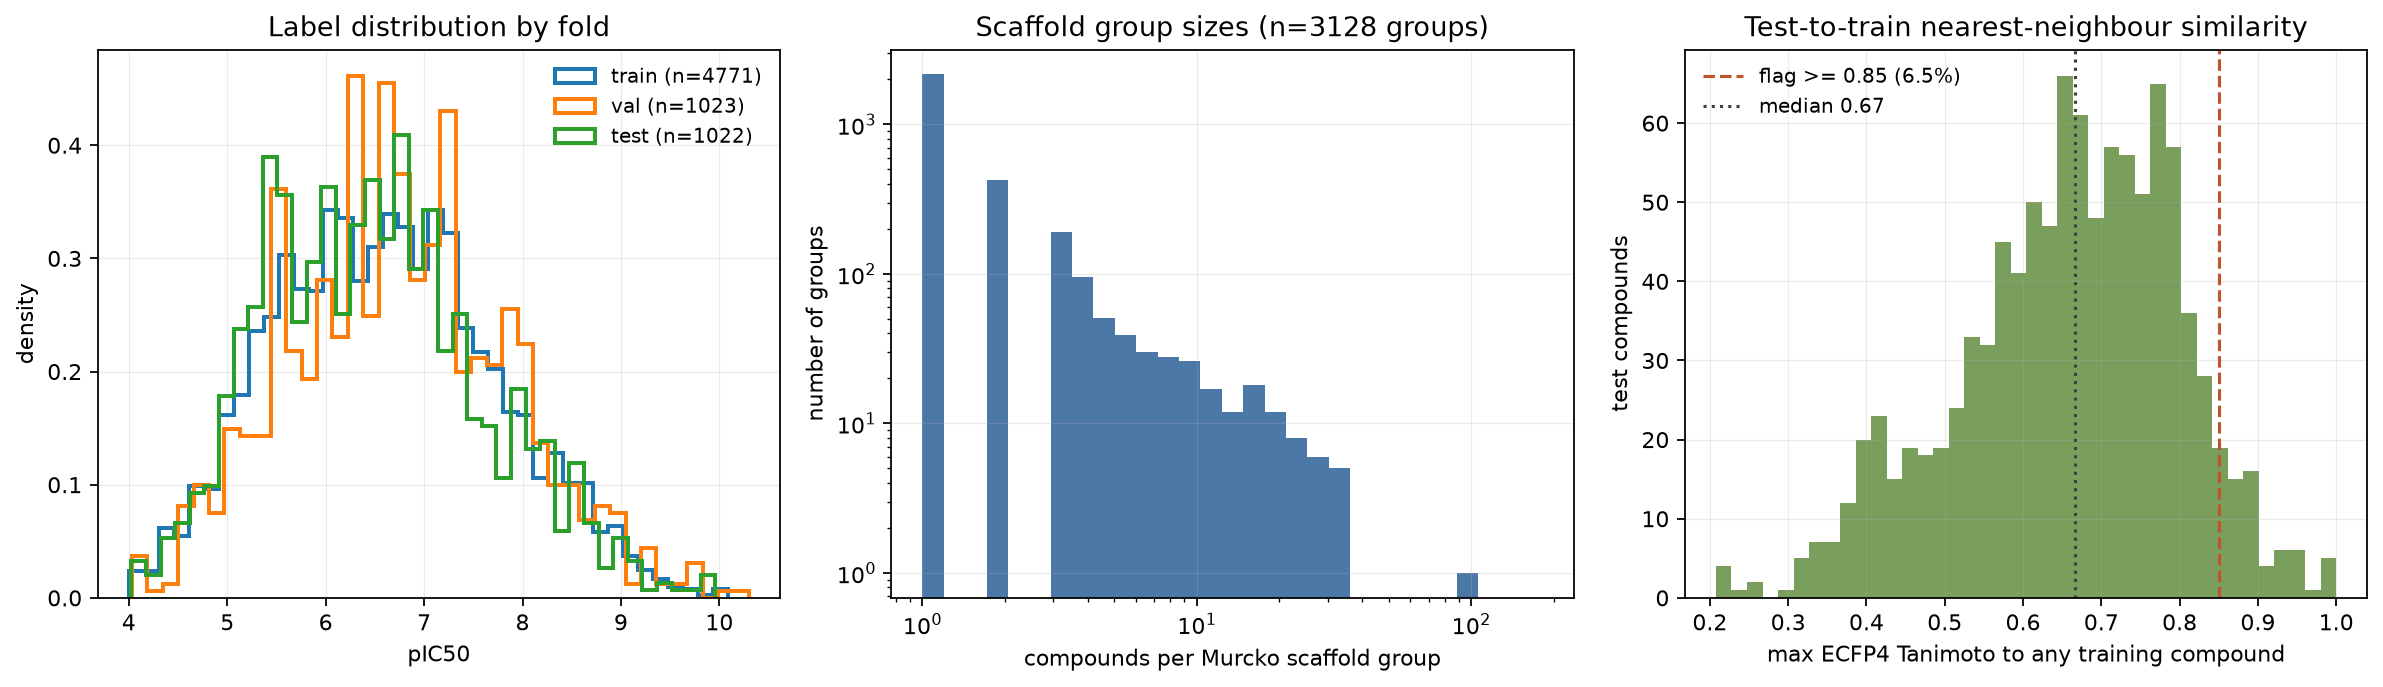

In [4]:
print("folds:", manifest["fold_sizes"])
print("fractions:", {k: round(v, 4) for k, v in manifest["fold_fractions"].items()})
print(f"{manifest['n_groups']} Murcko scaffold groups, {manifest['n_acyclic']} acyclic compounds")

failed = [g for g in gates["gates"] if not g["passed"] and g["severity"] == "fail"]
flagged = [g for g in gates["gates"] if not g["passed"] and g["severity"] == "flag"]
print("")
print(f"gates: {gates['n_gates']} run, {len(failed)} failed, {len(flagged)} flagged")
for g in flagged:
    print(f"  FLAG {g['name']}: {g['observed']}")
display(Image(filename=str(RESULTS / "fig_split_diagnostics.png")))

**On the absolute similarity level.** The median test-to-train Tanimoto is high in absolute
terms, because HDAC1's ChEMBL corpus is congeneric — nearly every compound is a zinc-binding group,
a linker and a cap. The relevant question is whether the scaffold split separates chemotypes better
than chance, which is why the gate is calibrated against a seeded random-split control rather than
an absolute constant.

In [5]:
sim = [g for g in gates["gates"] if "median" in g["name"] or "similarity" in g["name"]]
display(pd.DataFrame([{"gate": g["name"], "observed": g["observed"], "expected": g["expected"],
                       "severity": g["severity"], "passed": g["passed"]} for g in sim]))

,gate,observed,expected,severity,passed
0,L9_high_similarity_reduction,test frac>=0.85: 0.0568 vs random 0.2581 (4.5x...,>= 2.0x fewer than random split,fail,True
1,L10_median_below_random,test median=0.6625 vs random 0.7857 (margin +0...,at least 0.05 below the random-split median,fail,True
2,L10b_median_absolute,test median=0.6625 (dataset is congeneric; ran...,"recorded, not gated",info,True
3,L11b_high_similarity_reduction_val,val frac>=0.85: 0.0547 vs random 0.2581 (4.7x ...,>= 2.0x fewer than random split,fail,True
4,L11c_median_below_random_val,val median=0.7021 vs random 0.7857 (margin +0....,at least 0.05 below the random-split median,fail,True
5,L11d_median_absolute_val,val median=0.7021 (dataset is congeneric; rand...,"recorded, not gated",info,True


## 4. The comparison

In [6]:
table = pd.DataFrame(comparison["table"])[
    ["model", "rmse", "mae", "r2", "spearman", "cls_roc_auc", "cls_pr_auc", "cls_mcc"]
].rename(columns={"cls_roc_auc": "ROC-AUC", "cls_pr_auc": "PR-AUC", "cls_mcc": "MCC"})
display(table.round(4))

for pair, block in comparison["pairwise_deltas"].items():
    print("")
    print(f"Paired bootstrap - {pair}  (* = significant at 95%)")
    for metric, d in block.items():
        star = "*" if d["significant"] else " "
        print(f" {star} {metric:18s} {d['delta']:+.4f}  "
              f"[{d['lo']:+.4f}, {d['hi']:+.4f}]  p={d['p_value']:.3f}")

,model,rmse,mae,r2,spearman,ROC-AUC,PR-AUC,MCC
0,mean predictor,1.1060,0.9007,-0.0166,NaN,0.5000,0.3092,0.0000
1,majority class,1.2015,0.9499,-0.1997,NaN,0.5000,0.3092,0.0000
2,random scores,2.2340,1.8290,-3.1473,0.0085,0.4831,0.2926,0.0109
3,1-NN Tanimoto,0.9440,0.6530,0.2594,0.6566,0.8180,0.6593,0.4660
4,Random forest (ECFP4 + descriptors),0.7367,0.5640,0.5490,0.7594,0.8779,0.7784,0.5636
5,GINE graph neural network,0.7357,0.5535,0.5502,0.7456,0.8670,0.7563,0.5250
6,Chemprop D-MPNN,0.7312,0.5407,0.5557,0.7644,0.8801,0.7812,0.5650



Paired bootstrap - Random forest (ECFP4 + descriptors) vs GINE graph neural network  (* = significant at 95%)
   rmse               +0.0010  [-0.0307, +0.0293]  p=0.936
   mae                +0.0105  [-0.0124, +0.0319]  p=0.370
   r2                 -0.0012  [-0.0350, +0.0390]  p=0.936
   spearman           +0.0138  [-0.0076, +0.0361]  p=0.229
   pearson            +0.0042  [-0.0182, +0.0286]  p=0.725
   roc_auc            +0.0109  [-0.0041, +0.0262]  p=0.147
   pr_auc             +0.0221  [-0.0112, +0.0587]  p=0.205
   mcc                +0.0386  [-0.0132, +0.0953]  p=0.145
   balanced_accuracy  -0.0059  [-0.0322, +0.0226]  p=0.664

Paired bootstrap - Random forest (ECFP4 + descriptors) vs Chemprop D-MPNN  (* = significant at 95%)
   rmse               +0.0054  [-0.0280, +0.0372]  p=0.757
   mae                +0.0233  [-0.0003, +0.0466]  p=0.054
   r2                 -0.0066  [-0.0439, +0.0352]  p=0.757
   spearman           -0.0051  [-0.0297, +0.0190]  p=0.685
   pearson           

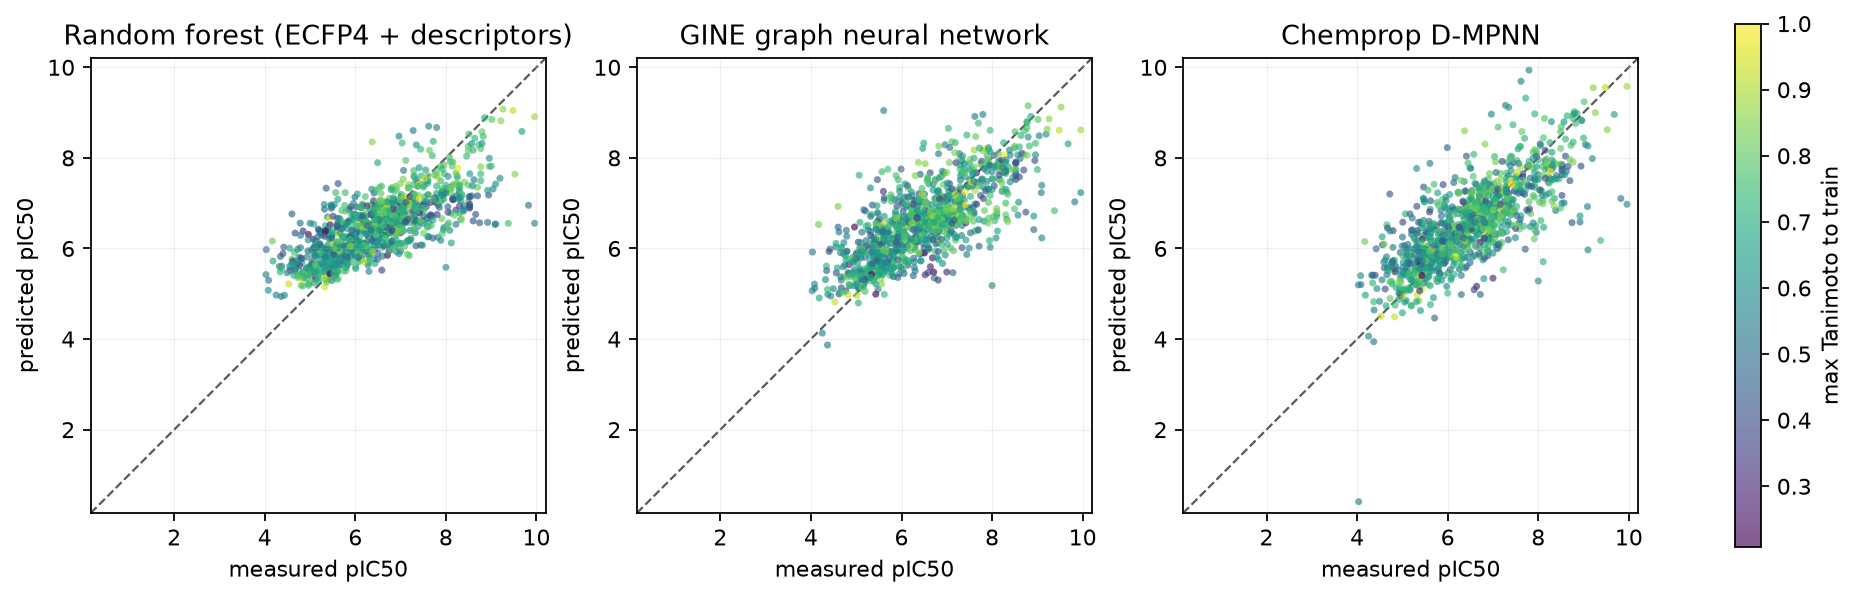

In [7]:
display(Image(filename=str(RESULTS / "fig_parity.png")))

## 5. Why — the diagnostics

The two analyses that turn "the models scored similarly" into an explanation.

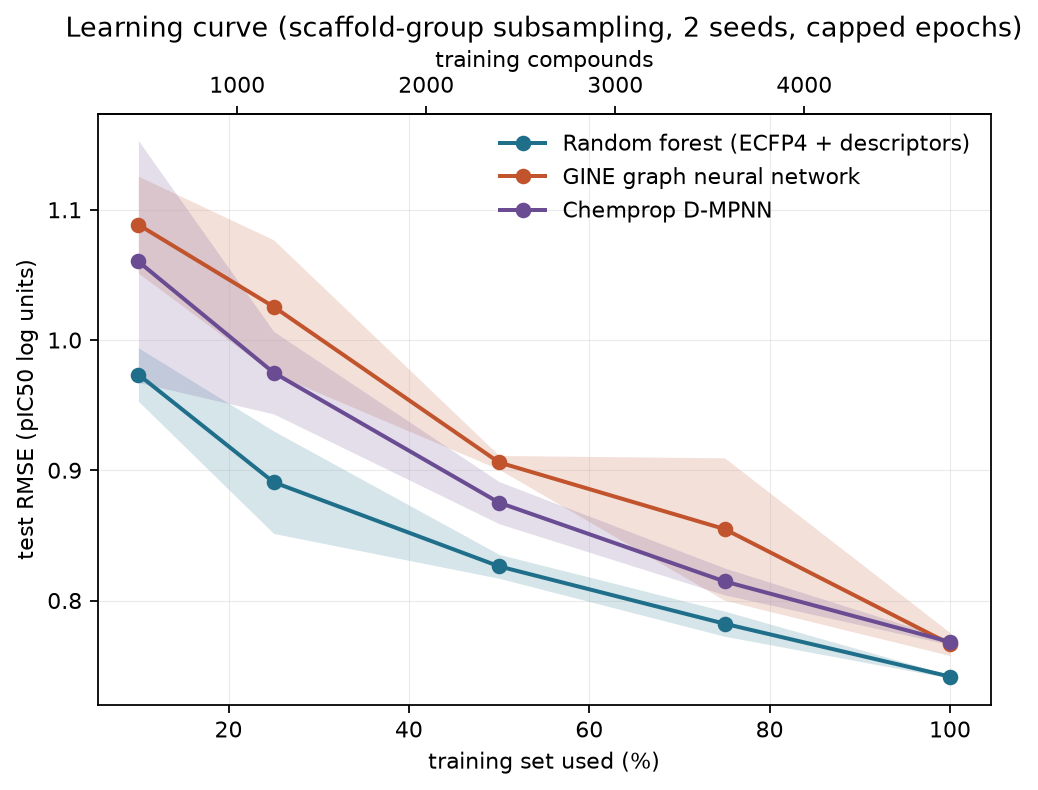

Random-split control - apparent accuracy bought by the protocol alone:


,model,random_rmse,scaffold_rmse,optimism,scaffold_rmse_ensembled,n_seeds_each_side
0,Random forest (ECFP4 + descriptors),0.6081,0.7370,0.1289,0.7367,1
1,GINE graph neural network,0.6215,0.7744,0.1529,0.7357,1
2,Chemprop D-MPNN,0.6075,0.7685,0.1610,0.7312,1


Optimism is large (~0.12-0.13 log units) for the random forest and the
field-standard D-MPNN alike. The GINE network gains less because it is the
weakest model under the random split, not because it resists leakage.


In [8]:
if diagnostics:
    display(Image(filename=str(RESULTS / "fig_learning_curve.png")))
    ctrl = diagnostics["random_split_control"]
    rows = [{"model": label, **{k: round(v, 4) for k, v in ctrl[label].items()}}
            for label in comparison["models"] if label in ctrl]
    print("Random-split control - apparent accuracy bought by the protocol alone:")
    display(pd.DataFrame(rows))
    print("Optimism is large (~0.12-0.13 log units) for the random forest and the")
    print("field-standard D-MPNN alike. The GINE network gains less because it is the")
    print("weakest model under the random split, not because it resists leakage.")
else:
    print("diagnostics.json not present; run scripts/07_diagnostics.py")

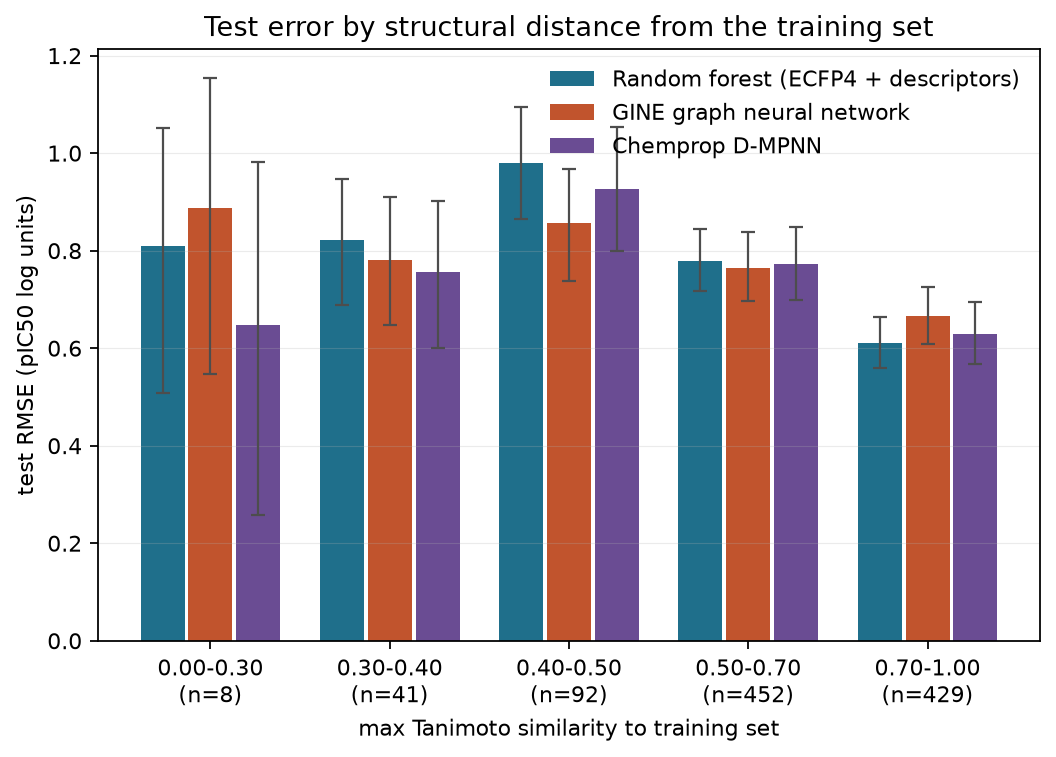

,similarity bin,n,Random forest (ECFP4 + descriptors),GINE graph neural network,Chemprop D-MPNN
0,0.00-0.30,8,0.8103,0.8882,0.6468
1,0.30-0.40,41,0.8215,0.7813,0.7556
2,0.40-0.50,92,0.9795,0.8559,0.9264
3,0.50-0.70,452,0.7780,0.7640,0.7734
4,0.70-1.00,429,0.6104,0.6666,0.6301


In [9]:
display(Image(filename=str(RESULTS / "fig_stratified_by_similarity.png")))

strat = comparison["stratified_by_similarity"]
display(pd.DataFrame({"similarity bin": strat["bins"], "n": strat["counts"],
                      **{m: np.round(strat[m], 4) for m in comparison["models"]}}))

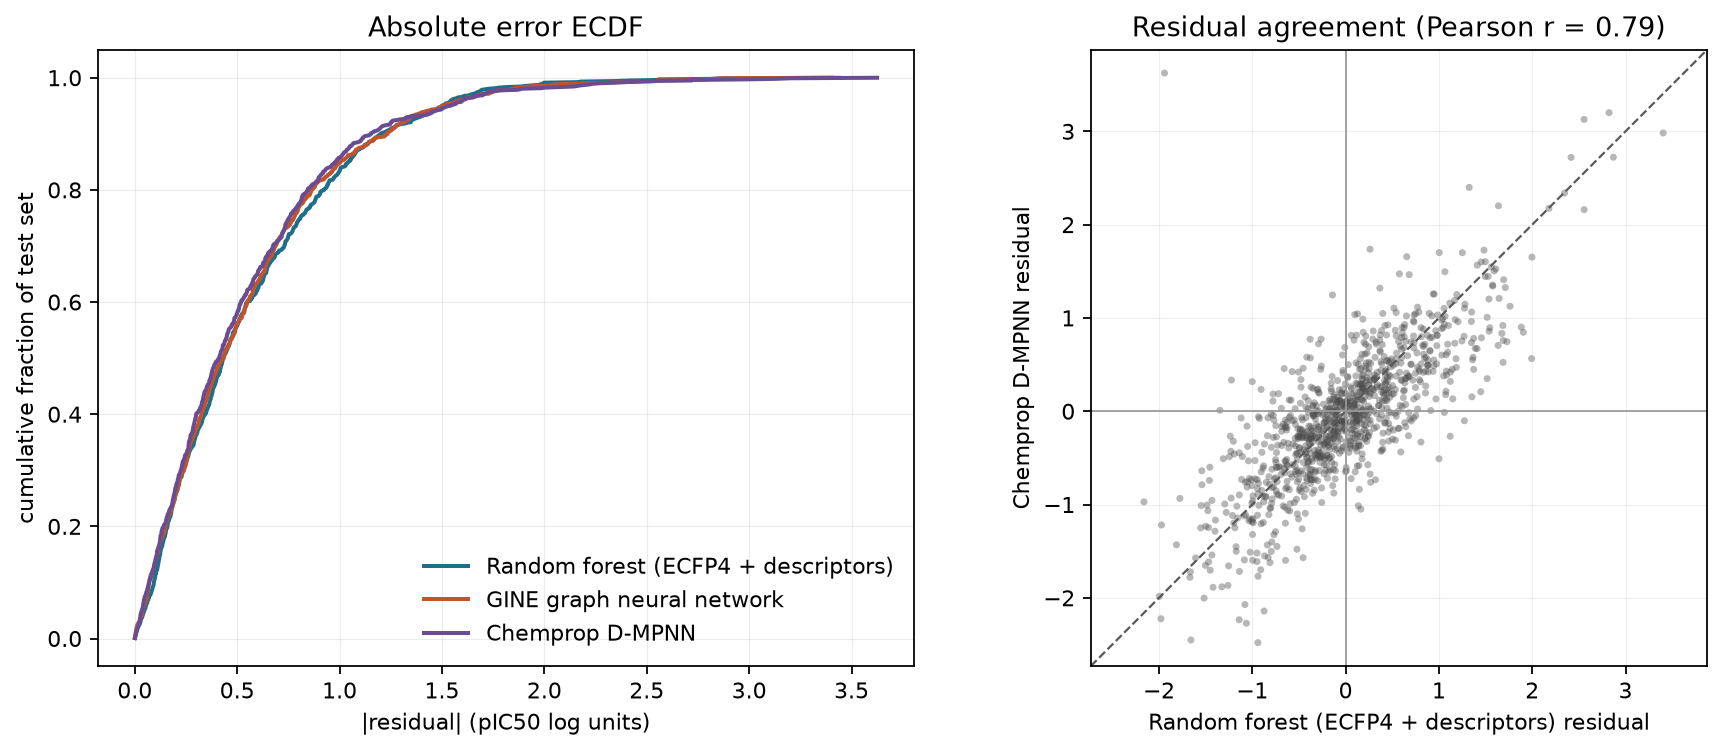

residual correlation between models:
  Random forest (ECFP4 + descriptors) vs GINE graph neural network: r = 0.852
  Random forest (ECFP4 + descriptors) vs Chemprop D-MPNN: r = 0.787
  GINE graph neural network vs Chemprop D-MPNN: r = 0.819

By number of independent measurements (a proxy for label quality):


,n,Random forest (ECFP4 + descriptors),GINE graph neural network,Chemprop D-MPNN
single measurement,933.0,0.729119,0.732317,0.720434
replicated (>=2),89.0,0.811591,0.770130,0.835961


In [10]:
display(Image(filename=str(RESULTS / "fig_error_distributions.png")))
print("residual correlation between models:")
for pair, r in comparison["residual_correlation"].items():
    print(f"  {pair}: r = {r:.3f}")
print("")
print("By number of independent measurements (a proxy for label quality):")
display(pd.DataFrame(comparison["stratified_by_replicates"]).T)

## 6. What the forest looked at

If the twelve bulk descriptors carried most of the signal, the headline comparison would really be
about molecular size and polarity rather than substructure. The ablations settle that.

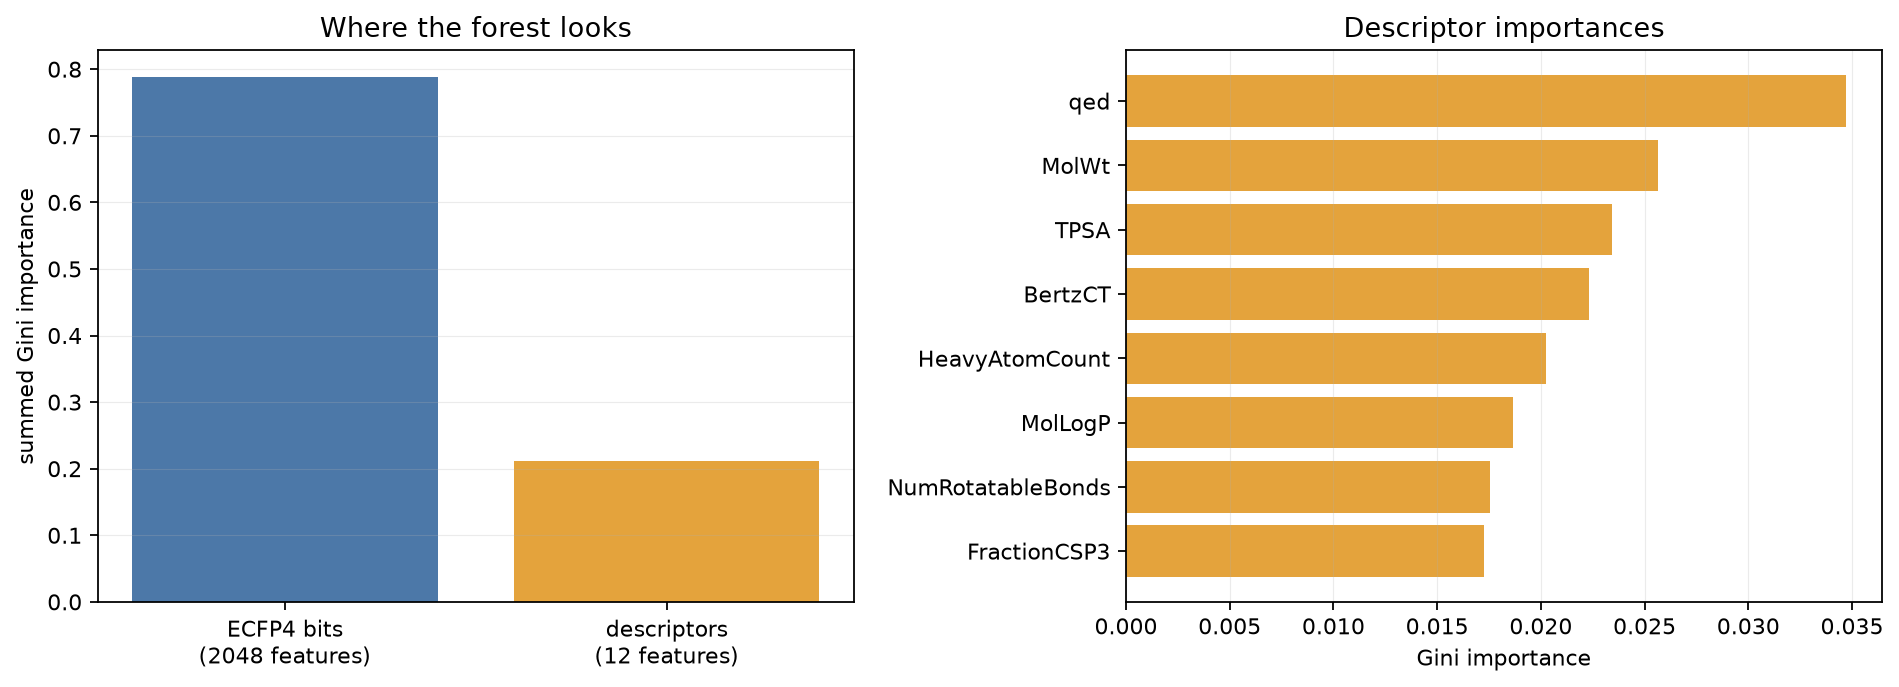

,n_features,rmse,spearman,r2
ecfp4_only,2048.0,0.7477,0.7404,0.5354
descriptors_only,12.0,0.9002,0.5682,0.3265
fcfp4_plus_desc,2060.0,0.7601,0.7420,0.5199
ecfp6_plus_desc,2060.0,0.7412,0.7534,0.5434


In [11]:
display(Image(filename=str(RESULTS / "fig_rf_importance.png")))
display(pd.DataFrame(model_metrics["random forest"]["ablations"]).T[
    ["n_features", "rmse", "spearman", "r2"]].round(4))

## 7. Does it replicate on other targets?

`scripts/10_multitarget.py` re-runs the core experiment on HDAC6 (same enzyme family) and hERG (a
different target class) under a reduced three-seed protocol, to test whether the split-dependence
effect is an HDAC1 artifact.

In [12]:
mt_path = RESULTS / "multitarget.json"
if mt_path.exists():
    mt = json.loads(mt_path.read_text(encoding="utf-8"))
    rows = []
    for short, block in mt["targets"].items():
        s = block["scaffold_split"]
        r = block["random_split"]
        o = block["optimism"]
        rows.append({
            "target": short, "n": block["n_compounds"],
            "RF scaffold": round(s["random_forest"]["rmse"], 4),
            "RF random": round(r["random_forest"]["rmse"], 4),
            "RF optimism": round(o["random_forest"], 4),
            "CP scaffold": round(s["chemprop"]["rmse"], 4),
            "CP random": round(r["chemprop"]["rmse"], 4),
            "CP optimism": round(o["chemprop"], 4),
        })
    display(pd.DataFrame(rows))
    print(mt["protocol"]["note"])
else:
    print("multitarget.json not present; run scripts/10_multitarget.py")

,target,n,RF scaffold,RF random,RF optimism,CP scaffold,CP random,CP optimism
0,HDAC1,6816,0.7371,0.6070,0.1301,0.7377,0.5665,0.1711
1,HDAC6,5509,0.6514,0.5860,0.0653,0.6837,0.5852,0.0985
2,hERG,7733,0.6596,0.5319,0.1276,0.6998,0.5272,0.1726


Reduced relative to the HDAC1 deep dive: 3 seeds not 5, Chemprop only, and the HDAC1 forest configuration reused rather than re-searched per target. Tests whether the split-dependence effect replicates, not each target's best achievable RMSE.


## 8. Limitations

See the README for the full list. The ones that bound every number above:

- **Label noise sets the floor.** The 6,816 compounds come from 1,046 assays across 720
  publications, so the labels carry inter-laboratory variation that no model can predict. Published
  reproducibility for ChEMBL IC50 data is roughly 0.5–0.7 log units, and all three models sit at
  ~0.73.
- **The study is only marginally powered.** The paired difference interval is about ±0.03 log
  units, so "no significant difference" reflects limited power as well as genuine similarity.
- **Stereochemistry is stripped**, because ChEMBL annotates it inconsistently across papers and
  keeping it would create phantom duplicate compounds that leak across folds.
- **Censored measurements are excluded**, which truncates the low-potency tail and makes every
  classification metric look slightly better than it should.
- **One target for the deep dive, three for the replication, in silico only.** Nothing here was
  tested experimentally.